# 05. 기후에 따른 피해 예측

| 항목 | 내용 |
|---|---|
| 목적 | 기상이 업종 매출을 얼마나 줄이는지 **예측 모델로 정량화**하고, 업종·지역별 **피해율·피해액·연간 예상 손실**을 산출한다 |
| 입력 | `data/processed/model_daily_group.parquet`, `unit_profile.parquet`, 기상청 일자료(연간 발생 빈도) |
| 출력 | `damage_daily.parquet`(일별 피해), `damage_unit_summary.parquet`(지원금 최적화 입력), `damage_model_coef.parquet`(최종 모델 기상 계수) |
| 브랜치 | `ana-pred` |

### 피해를 어떻게 정의하나 — 반사실(counterfactual) 예측
같은 모델에 두 가지 날씨를 넣어 매출을 예측하고, 그 차이를 기상 피해로 본다.

| 시나리오 | 입력 날씨 |
|---|---|
| **실제** | 그날 실제 관측된 날씨 (예보를 넣으면 '내일 예상 피해') |
| **기준(평소)** | 비·눈 없음, 체감온도·최저기온은 **같은 날짜의 10년 평년값** |

$$\text{피해율} = \frac{\hat{y}_{\text{실제}}}{\hat{y}_{\text{기준}}} - 1, \qquad \text{기준 매출} = \frac{\text{실제 매출}}{1 + \text{피해율}}, \qquad \text{피해액} = \text{기준 매출} - \text{실제 매출}$$

피해율이 음수면 매출 감소(피해), 양수면 증가다. 금액은 모두 **신한카드 개인 결제 기준**이다.

**진행 순서**
1. 환경 설정·데이터
2. 모델 후보와 검증 방법
3. 모델 비교 (블록 교차검증)
4. 최종 모델 해석 (업종별 기상 계수)
5. 반사실 피해 산출 (교차검증 예측 사용)
6. 기상 유형 × 업종 피해 — **가설 3**
7. 업체 규모와 피해 — **가설 1**
8. 연간 예상 손실 — 지원금 최적화 입력 (**가설 2** 준비)
9. 예보 시나리오
10. 저장·정리

## 1. 환경 설정·데이터

In [1]:
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr
from sklearn.linear_model import LassoCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:,.2f}'.format)

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data'
PROC = DATA / 'processed'
load = lambda name: pd.read_parquet(PROC / f'{name}.parquet')

INK, INK2, GRID, SURFACE = '#0b0b0b', '#52514e', '#e4e3df', '#fcfcfb'
REGION_COLOR = {'강남구': '#2a78d6', '춘천시': '#eb6834'}
MID = '#f0efec'
DIV = LinearSegmentedColormap.from_list('div_red_blue', ['#c43a3a', '#e34948', '#f2a3a2', MID, '#9ec5f4', '#2a78d6', '#1c5cab'])
plt.rcParams.update({
    'font.family': 'Malgun Gothic', 'axes.unicode_minus': False, 'figure.dpi': 110,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK2, 'xtick.color': INK2, 'ytick.color': INK2,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlecolor': INK, 'axes.titlelocation': 'left',
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False, 'lines.linewidth': 2, 'legend.frameon': False,
})
REGIONS = ['강남구', '춘천시']
KEYS = ['region', 'industry_group']

full = load('model_daily_group')
unit = load('unit_profile')
df = full[full['use_for_model']].reset_index(drop=True)
df['unit'] = df['region'] + '|' + df['industry_group']
# 기준 시나리오에 필요한 평년값 복원 (편차 = 실제 − 평년)
df['normal_feels_like'] = df['feels_like_max'] - df['anom_feels_like']
df['normal_temp_min'] = df['temp_min'] - df['anom_temp_min']
print(f"학습 데이터 {df.shape}, 기간 {df['date'].min():%Y-%m-%d} ~ {df['date'].max():%Y-%m-%d}")

학습 데이터 (5100, 82), 기간 2025-07-15 ~ 2025-12-31


## 2. 모델 후보와 검증 방법

| 모델 | 입력 | 의도 |
|---|---|---|
| **M0 LightGBM — 날씨 없음** | 지역·업종, 달력, 최근 매출 수준 | 날씨 없이 얼마나 맞히나 (기준선) |
| **M1 선형 회귀 — 날씨 없음** | 단위(지역×업종)별 수준·요일·공휴일 효과 + 최근 매출 수준 | 선형 기준선 |
| **M2 선형 회귀 — 단위별 기상 계수** | M1 + 기상 사건 변수 × 30개 단위별 계수 | 업종·지역마다 기상 반응이 다르다는 EDA 결과를 그대로 반영, 해석 가능 |
| **M3 LASSO** (표준화 + L1) | M2와 같은 변수 | 많은 상호작용 중 필요한 것만 남김. **표준화는 학습 구간에서만 맞춰 적용** |
| **M4 LightGBM — 원값 기상** | M0 + 엔지니어링 전 기상 원값 (일강수량·시간대 강수·체감온도·최저기온·신적설 등) | 엔지니어링 효과 비교용 |
| **M5 LightGBM — 엔지니어링 기상 전체** | M0 + 기상 사건 변수 + 평년 편차·풍속 | 4단계 변수 전체 |
| **M6 LightGBM — 기상 사건 + 단조 제약** | M0 + 기상 사건 변수, 강수 노출이 늘면 매출이 늘 수 없음 | 비현실적 반사실 방지 |

기상 사건 변수 = 영업시간 강수 노출(log), 전날 비(log), 연속 강수일, 폭염 30~33℃·33℃↑, 눈, 적설 잔존, 한파

**검증**: 날짜 순서대로 5개 블록으로 나누고 한 블록씩 빼고 학습·예측한다 (**블록 교차검증**). 무작위로 섞으면 인접한 날의 정보가 새어 성능이 부풀려진다.

**지표**: WAPE = Σ|실제 − 예측| ÷ Σ실제 (매출 금액 기준 오차율). 전체 일자와 **강한 비·폭염·눈 일자**를 따로 본다 — 날씨 모델은 '날씨가 나쁜 날'을 잘 맞혀야 한다.

> **스케일링**: LightGBM(트리)과 OLS에는 스케일링을 하지 않는다. LASSO는 벌점이 변수 크기에 좌우되므로 `StandardScaler`를 파이프라인에 넣어 **각 학습 블록에서만 평균·표준편차를 구하고** 검증 블록에 적용한다 (누수 방지).

In [2]:
BASE = ['region_code', 'industry_code', 'dow_num', 'is_holiday', 'is_offday', 'holiday_prev', 'holiday_next',
        'is_payday_week', 'lag7', 'lag14', 'roll7']
W_RAW = ['rain_sum', 'rain_00_05', 'rain_06_11', 'rain_12_17', 'rain_18_23', 'rain_prev',
         'feels_like_max', 'temp_min', 'wind_mean', 'snow_new']
W_ENG = ['log_rain_exposure', 'log_rain_prev', 'rain_streak', 'heat_30_33', 'heat_33', 'anom_feels_like',
         'anom_temp_min', 'cold', 'snow', 'snow_cover', 'wind_mean']
W_EVENT = ['log_rain_exposure', 'log_rain_prev', 'rain_streak', 'heat_30_33', 'heat_33', 'snow', 'snow_cover', 'cold']
LIN_W = ['log_rain_exposure', 'log_rain_prev', 'heat_30_33', 'heat_33', 'snow', 'cold']   # 선형 모델의 단위별 기상 계수
LGB_PARAMS = dict(objective='regression', learning_rate=0.03, n_estimators=800, num_leaves=15,
                  min_child_samples=20, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                  reg_lambda=1.0, random_state=42, verbose=-1)

class LGBModel:
    def __init__(self, features, monotone=None):
        self.features = features
        cons = [(-1 if f in (monotone or {}) else 0) for f in features]
        self.m = lgb.LGBMRegressor(**LGB_PARAMS, monotone_constraints=cons)
    def fit(self, d):
        self.m.fit(d[self.features], d['log_amt'], categorical_feature=['region_code', 'industry_code'])
        return self
    def predict(self, d):
        return self.m.predict(d[self.features])

LIN_BASE = ('log_amt ~ C(unit) + C(unit):(C(dow_num) + is_holiday) + lag7 + lag14 + roll7 + holiday_prev + holiday_next'
            ' + is_payday_week')
LIN_FORMULA = LIN_BASE + ' + C(unit):(' + ' + '.join(LIN_W) + ')'

class OLSModel:
    # 단위에 그 기상이 한 번도 없으면(예: 강남 한파) 해당 계수는 0으로 추정된다 (최소노름 해).
    def __init__(self, formula=LIN_FORMULA):
        self.formula = formula
    def fit(self, d):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            self.res = smf.ols(self.formula, data=d).fit()
        return self
    def predict(self, d):
        return np.asarray(self.res.predict(d))

class LassoModel:
    """OLS와 같은 설계행렬 → 표준화(학습 구간 기준) → LASSO(학습 구간 안에서 3겹 CV로 벌점 선택)."""
    def fit(self, d):
        import patsy
        self.design = patsy.dmatrix(LIN_FORMULA.split('~')[1], d, return_type='dataframe').design_info
        X = patsy.build_design_matrices([self.design], d, return_type='dataframe')[0].drop(columns='Intercept')
        self.cols = X.columns
        self.pipe = make_pipeline(StandardScaler(), LassoCV(cv=3, alphas=30, max_iter=20000, random_state=42))
        self.pipe.fit(X.values, d['log_amt'].values)
        return self
    def predict(self, d):
        import patsy
        X = patsy.build_design_matrices([self.design], d, return_type='dataframe')[0].drop(columns='Intercept')
        return self.pipe.predict(X[self.cols].values)

MODELS = {
    'M0 LGBM 날씨 없음': lambda: LGBModel(BASE),
    'M1 선형 날씨 없음': lambda: OLSModel(LIN_BASE),
    'M2 선형 단위별 기상': lambda: OLSModel(),
    'M3 LASSO(표준화)': lambda: LassoModel(),
    'M4 LGBM 원값 기상': lambda: LGBModel(BASE + W_RAW),
    'M5 LGBM 엔지니어링 전체': lambda: LGBModel(BASE + W_ENG),
    'M6 LGBM 사건+단조': lambda: LGBModel(BASE + W_EVENT, monotone={'log_rain_exposure', 'rain_streak'}),
}
N_BLOCKS = 5
df['block'] = pd.qcut(df['date'].rank(method='dense'), N_BLOCKS, labels=False)
print(df.groupby('block')['date'].agg(['min', 'max']).apply(lambda c: c.dt.strftime('%m-%d')))

         min    max
block              
0      07-15  08-17
1      08-18  09-20
2      09-21  10-24
3      10-25  11-27
4      11-28  12-31


## 3. 모델 비교 (블록 교차검증)

In [3]:
oof, fold_models = {}, {}
for name, make in MODELS.items():
    p = np.empty(len(df)); fold_models[name] = []
    for b in range(N_BLOCKS):
        test = (df['block'] == b).values
        m = make().fit(df[~test])
        p[test] = m.predict(df[test])
        fold_models[name].append(m)
    oof[name] = p
    print(f'완료: {name}')

day_type = np.select([df['rain_heavy'] == 1, df['heat_33'] == 1, (df['snow'] == 1) | (df['cold'] == 1)],
                     ['강한 비 일자', '폭염 일자', '눈·한파 일자'], '그 외 일자')
rows = []
for name, p in oof.items():
    f = df[['region', 'amount', 'log_amt']].assign(pred=np.expm1(p), day_type=day_type, weather_day=day_type != '그 외 일자')
    for subset, part in [('전체', f), *f.groupby('day_type')]:
        for region, r in [('전체', part), *part.groupby('region')]:
            rows.append({'model': name, 'subset': subset, 'region': region, 'n': len(r),
                         'WAPE(%)': (r['amount'] - r['pred']).abs().sum() / r['amount'].sum() * 100})
metrics = pd.DataFrame(rows)
wd = []
for name, p in oof.items():
    m = (day_type != '그 외 일자')
    a, pr = df.loc[m, 'amount'], np.expm1(p[m])
    wd.append({'model': name, 'subset': '기상 일자 전체', 'region': '전체', 'n': int(m.sum()), 'WAPE(%)': (a - pr).abs().sum() / a.sum() * 100})
metrics = pd.concat([metrics, pd.DataFrame(wd)], ignore_index=True)
metrics[metrics['region'] == '전체'].pivot(index='model', columns='subset', values='WAPE(%)')[
    ['전체', '기상 일자 전체', '강한 비 일자', '폭염 일자', '눈·한파 일자', '그 외 일자']].round(2)

완료: M0 LGBM 날씨 없음


완료: M1 선형 날씨 없음


완료: M2 선형 단위별 기상


완료: M3 LASSO(표준화)


완료: M4 LGBM 원값 기상


완료: M5 LGBM 엔지니어링 전체


완료: M6 LGBM 사건+단조


subset,전체,기상 일자 전체,강한 비 일자,폭염 일자,눈·한파 일자,그 외 일자
model,,,,,,
M0 LGBM 날씨 없음,12.67,10.80,12.77,9.81,8.26,13.15
M1 선형 날씨 없음,11.13,10.23,12.01,9.09,9.88,11.36
M2 선형 단위별 기상,11.43,9.87,11.30,8.86,10.51,11.82
M3 LASSO(표준화),14.60,12.50,11.49,13.59,8.91,15.14
M4 LGBM 원값 기상,13.83,11.07,11.69,11.03,8.05,14.54
M5 LGBM 엔지니어링 전체,13.65,11.25,12.78,10.45,9.64,14.26
M6 LGBM 사건+단조,12.80,10.40,11.83,9.81,7.51,13.42


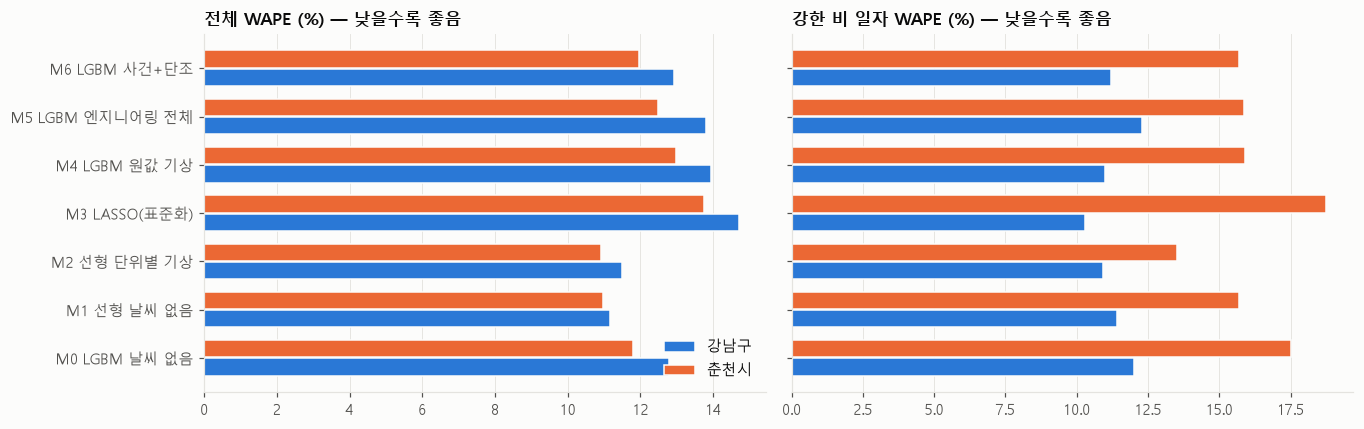

In [4]:
mv = metrics[(metrics['subset'].isin(['전체', '강한 비 일자'])) & (metrics['region'] != '전체')]
piv = mv.pivot_table(index='model', columns=['subset', 'region'], values='WAPE(%)')
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4), sharey=True)
names = list(MODELS)
for ax, subset in zip(axes, ['전체', '강한 비 일자']):
    y = np.arange(len(names))
    for k, r in enumerate(REGIONS):
        ax.barh(y + (k - 0.5) * 0.38, piv.loc[names, (subset, r)], height=0.36, color=REGION_COLOR[r], label=r, edgecolor=SURFACE)
    ax.set_yticks(y, names); ax.invert_yaxis()
    ax.set_title(f'{subset} WAPE (%) — 낮을수록 좋음', fontsize=11)
    ax.grid(axis='y', visible=False)
axes[0].legend(loc='lower right')
fig.tight_layout()

**해석 — 최종 모델 선택**
- **선형 회귀(M2, 단위별 기상 계수)를 최종 모델로 고른다.** 기상이 있는 날 전체 오차가 9.87%로 가장 낮고, 강한 비 날(11.30%)·폭염 날(8.86%)도 가장 낮다. 날씨 없는 선형 모델(M1)과 비교하면 강한 비 날 오차가 12.01% → 11.30%로 줄어 **날씨 정보가 실제로 기여**한다.
- 전체 오차는 M1(11.13%)이 조금 더 낮다. 날씨 계수가 평범한 날에는 잡음이 되기 때문이다. 하지만 이 모델의 목적은 '날씨가 나쁜 날의 피해'를 재는 것이므로 기상 일자 오차를 기준으로 고른다.
- LightGBM은 이 데이터(6개월, 30개 단위)에서 선형 모델보다 못했다. 다만 **엔지니어링 변수의 효과는 분명하다**: 원값 기상(M4) → 기상 사건 변수(M6)로 바꾸자 전체 13.83% → 12.80%, 기상 일자 11.07% → 10.40%로 좋아졌다. 평년 편차·풍속까지 넣은 M5는 오히려 나빠졌는데, EDA에서 기온 효과가 없었던 것과 같은 결과다.
- LASSO는 표준화 후 벌점이 단위별 달력 효과까지 깎아 전체 오차가 컸다 (14.60%).

## 4. 최종 모델 해석 (업종별 기상 계수)

**최종 모델 = M2 (선형 회귀 — 단위별 기상 계수)**. 선택 이유는 위 비교 결과에 정리했다.
전체 기간으로 다시 학습하고, 30개 단위별 기상 계수를 **효과(%) = e^계수 − 1**로 바꿔 본다. 표준오차는 같은 날짜의 업종끼리 오차가 비슷한 점을 반영해 **날짜 단위 군집 표준오차**를 쓴다.

In [5]:
FINAL = 'M2 선형 단위별 기상'
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    final_res = smf.ols(LIN_FORMULA, data=df).fit(cov_type='cluster', cov_kwds={'groups': df['date'].rank(method='dense').astype(int)})
final = OLSModel(); final.res = final_res

rows = []
for name, b in final_res.params.items():
    if not name.startswith('C(unit)[') or ':' not in name:
        continue
    u, term = name.split(':', 1)
    if term not in LIN_W:
        continue
    reg, grp = u[len('C(unit)[') : -1].split('|')
    se = final_res.bse[name]
    rows.append({'region': reg, 'industry_group': grp, 'term': term, 'coef': b, 'se': se, 'p_value': final_res.pvalues[name]})
coef = pd.DataFrame(rows)
coef = coef[coef['se'] > 0].copy()          # 그 기상이 없던 단위(계수 0으로 고정)는 제외
coef['effect_pct'] = (np.exp(coef['coef']) - 1) * 100
coef['ci_low'] = (np.exp(coef['coef'] - 1.96 * coef['se']) - 1) * 100
coef['ci_high'] = (np.exp(coef['coef'] + 1.96 * coef['se']) - 1) * 100
LABEL = {'log_rain_exposure': '영업시간 강수 log 1단위', 'log_rain_prev': '전날 비 log 1단위', 'heat_30_33': '폭염 30~33℃',
         'heat_33': '폭염 33℃↑', 'snow': '눈', 'cold': '한파'}
coef['기상'] = coef['term'].map(LABEL)
print(f"전체 설명력 R² = {final_res.rsquared:.3f} | 기상 계수 {len(coef)}개 중 p<0.05: {(coef['p_value'] < 0.05).sum()}개")
print('영업시간 강수 노출 log(1+mm)가 1 늘 때(예: 0 → 1.7mm, 1.7 → 6.4mm, 6.4 → 19mm)의 매출 효과(%)')
coef[(coef['term'] == 'log_rain_exposure')].pivot(index='industry_group', columns='region', values='effect_pct').sort_values('춘천시').round(2)

전체 설명력 R² = 0.987 | 기상 계수 180개 중 p<0.05: 54개
영업시간 강수 노출 log(1+mm)가 1 늘 때(예: 0 → 1.7mm, 1.7 → 6.4mm, 6.4 → 19mm)의 매출 효과(%)


region,강남구,춘천시
industry_group,,
여가·오락,-1.16,-12.95
숙박,1.80,-8.69
기타소매,-0.69,-8.47
의류·잡화,-3.69,-8.47
카페·디저트,-2.44,-5.78
교통·자동차,-1.94,-5.63
주점·유흥,-1.48,-5.36
식료품소매,-5.91,-5.24
대형유통,-5.18,-4.02


**해석**
- 180개 기상 계수 중 54개가 유의하다. **춘천은 거의 모든 업종에서 강수 계수가 음수**이고, 여가·오락(−13%), 숙박·기타소매·의류·잡화(−8~−9%)가 크다. 강남은 계수가 작고 업종에 따라 부호가 섞인다.
- 영업시간 강수 노출 log 값이 1 늘어나는 것은 강수량이 약 2.7배 늘어나는 것과 비슷하다 (예: 6.4mm → 19mm). 즉 춘천 여가·오락은 영업시간에 오는 비가 2.7배가 될 때마다 매출이 약 13%씩 줄어든다.

## 5. 반사실 피해 산출

학습에 쓴 날을 그대로 예측하면 모델이 그날을 '외운' 결과가 섞인다. 그래서 **교차검증 예측**을 쓴다: 각 날짜는 그 날짜가 포함되지 않은 블록으로 학습한 모델로 '실제'와 '기준' 두 시나리오를 예측한다.

In [6]:
def baseline(d):
    """기준(평소) 시나리오: 비·눈 없음, 체감·최저기온은 평년값."""
    b = d.copy()
    for c in ['log_rain_exposure', 'log_rain_prev', 'rain_streak', 'snow', 'snow_cover', 'anom_feels_like', 'anom_temp_min']:
        b[c] = 0
    b['heat_30_33'] = b['normal_feels_like'].between(30, 33, inclusive='left').astype(int)
    b['heat_33'] = (b['normal_feels_like'] >= 33).astype(int)
    b['cold'] = (b['normal_temp_min'] <= -12).astype(int)
    return b

def damage_from(models, d):
    pa, pb = np.empty(len(d)), np.empty(len(d))
    for b, m in enumerate(models):
        t = (d['block'] == b).values
        pa[t] = m.predict(d[t]); pb[t] = m.predict(baseline(d[t]))
    return pa, pb

pa, pb = damage_from(fold_models[FINAL], df)
dmg = df[['date', 'region', 'industry_group', 'unit', 'amount', 'weather_type', 'rain_sum', 'rain_heavy', 'rain_mid',
          'heat_33', 'snow', 'cold', 'is_offday', 'alert_level']].copy()
dmg['pred_actual'], dmg['pred_base'] = pa, pb
dmg['damage_rate'] = (np.exp(pa - pb) - 1) * 100
dmg['base_amount'] = dmg['amount'] / (1 + dmg['damage_rate'] / 100)
dmg['damage_amount'] = dmg['base_amount'] - dmg['amount']        # 양수 = 기상으로 줄어든 매출
print('기상 유형별 평균 피해율(%) — 지역 전체 매출 가중')
w_rate = dmg.groupby(['region', 'weather_type'], observed=True).apply(
    lambda g: -g['damage_amount'].sum() / g['base_amount'].sum() * 100).unstack(0)
display(w_rate.round(2))
tot = dmg.groupby('region').agg(sales=('amount', 'sum'), loss=('damage_amount', lambda s: s.clip(lower=0).sum()),
                                net=('damage_amount', 'sum'))
tot['손실/매출(%)'] = tot['loss'] / tot['sales'] * 100
print('분석 기간(7/15~12/31) 기상 피해 합계 (억원) — loss = 피해만 합산, net = 증가분 상계')
(tot.assign(sales=tot['sales'] / 1e8, loss=tot['loss'] / 1e8, net=tot['net'] / 1e8)).round(1)

기상 유형별 평균 피해율(%) — 지역 전체 매출 가중


region,강남구,춘천시
weather_type,,
눈,-2.70,-4.10
강한 비,-4.15,-8.31
폭염,1.79,-1.50
한파,NaN,-0.00
비,-2.72,-3.39
평상,-0.85,0.46


분석 기간(7/15~12/31) 기상 피해 합계 (억원) — loss = 피해만 합산, net = 증가분 상계


,sales,loss,net,손실/매출(%)
region,,,,
강남구,"110,157.10","2,176.00","1,233.40",2.00
춘천시,"14,061.30",266.50,173.80,1.90


In [7]:
# 교차 확인: 모델의 강한 비 피해율 vs EDA 회귀 효과 (업종·지역 30개 단위)
eda = load('eda_effect_group')
eda_h = eda[eda['term'] == '비 강(30mm~)'].set_index(KEYS)['effect_pct']
mod_h = dmg[dmg['rain_heavy'] == 1].groupby(KEYS).apply(lambda g: (g['amount'].sum() / g['base_amount'].sum() - 1) * 100)
pa6, pb6 = damage_from(fold_models['M6 LGBM 사건+단조'], df)
h6 = df.assign(base6=np.expm1(pb6), act6=np.expm1(pa6))[df['rain_heavy'] == 1].groupby(KEYS).apply(
    lambda g: (g['act6'].sum() / g['base6'].sum() - 1) * 100)
cmp = pd.concat({'최종 모델(M2) 피해율(%)': mod_h, 'LightGBM(M6) 피해율(%)': h6, 'EDA 회귀 효과(%)': eda_h}, axis=1).dropna()
print('강한 비 날 효과 — 세 방법의 순위 상관 (30개 단위, 음수 = 매출 감소)')
display(cmp.corr(method='spearman').round(2))
print('지역 평균')
cmp.groupby(level=0).mean().round(2)

강한 비 날 효과 — 세 방법의 순위 상관 (30개 단위, 음수 = 매출 감소)


,최종 모델(M2) 피해율(%),LightGBM(M6) 피해율(%),EDA 회귀 효과(%)
최종 모델(M2) 피해율(%),1.00,0.52,0.71
LightGBM(M6) 피해율(%),0.52,1.00,0.35
EDA 회귀 효과(%),0.71,0.35,1.00


지역 평균


,최종 모델(M2) 피해율(%),LightGBM(M6) 피해율(%),EDA 회귀 효과(%)
region,,,
강남구,-4.09,-5.08,-0.39
춘천시,-8.44,-8.59,-7.77


**해석**
- 최종 모델의 기상 유형별 피해율: **강한 비 강남 −4.2% · 춘천 −8.3%**, 비 −2.7% · −3.4%, 눈 −2.7% · −4.1%. 폭염은 강남 +1.8%(증가), 춘천 −1.5%.
- 7/15~12/31 기상 피해(손실만 합산)는 강남 약 2,176억원(매출의 2.0%), 춘천 약 267억원(1.9%)이다 (신한카드 기준).
- '평상' 날에도 피해율이 0이 아닌 것은 **전날 비**의 영향과, 평년보다 시원한 여름날(평년 기준으로는 폭염 구간인 날)이 반영되기 때문이다.
- **교차 확인**: 강한 비 효과의 업종 순위가 EDA 회귀(주 고정효과)와 ρ = 0.71로 잘 맞는다. LightGBM(M6)과는 0.52다.
- 단, **강남 평균 피해율(−4.1%)은 EDA 회귀(−0.4%, 유의하지 않음)보다 크다.** 강남 피해는 '상한' 쪽으로 해석하고, 춘천(모델 −8.4% vs EDA −7.8%)은 두 방법이 일치한다.

## 6. 기상 유형 × 업종 피해 — 가설 3
기상 유형별로 그 유형인 날의 평균 피해율(기준 매출 대비 %)을 업종마다 계산한다. 같은 업종이라도 유형에 따라 피해의 방향(감소·증가)과 크기가 다른지 본다.

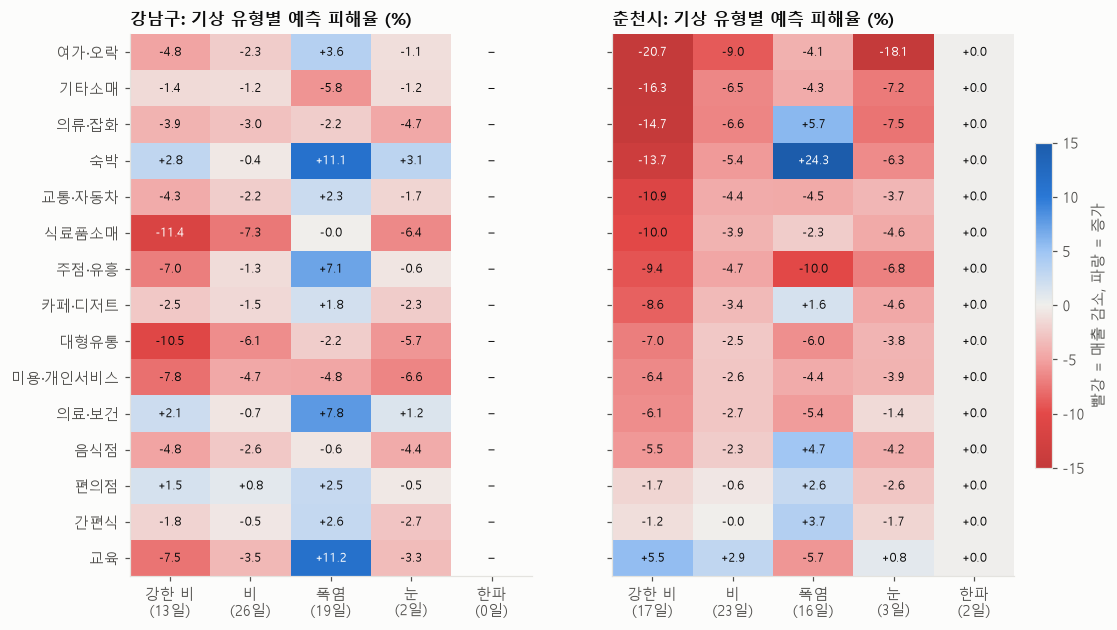

In [8]:
types = ['강한 비', '비', '폭염', '눈', '한파']
rate = (dmg.groupby(KEYS + ['weather_type'], observed=True)
           .apply(lambda g: (g['amount'].sum() / g['base_amount'].sum() - 1) * 100).unstack('weather_type'))
ndays = dmg.drop_duplicates(['date', 'region']).groupby(['region', 'weather_type'], observed=True).size().unstack()
order = rate.xs('춘천시').reindex(columns=types)['강한 비'].sort_values().index
fig, axes = plt.subplots(1, 2, figsize=(12.5, 6.4), sharey=True)
for ax, r in zip(axes, REGIONS):
    m = rate.xs(r).reindex(index=order, columns=types)
    im = ax.imshow(m.values, cmap=DIV, vmin=-15, vmax=15, aspect='auto')
    ax.set_xticks(range(len(types)), [f"{t}\n({int(ndays.loc[r, t]) if t in ndays.columns and pd.notna(ndays.loc[r, t]) else 0}일)" for t in types])
    ax.set_yticks(range(len(m)), m.index)
    ax.grid(False)
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            v = m.values[i, j]
            ax.text(j, i, '–' if pd.isna(v) else f'{v:+.1f}', ha='center', va='center', fontsize=8,
                    color='white' if pd.notna(v) and abs(v) > 11 else INK)
    ax.set_title(f'{r}: 기상 유형별 예측 피해율 (%)', fontsize=11)
cb = fig.colorbar(im, ax=axes, shrink=0.6, pad=0.02)
cb.set_label('빨강 = 매출 감소, 파랑 = 증가', color=INK2)

In [9]:
# 기상 유형에 따라 방향이 바뀌는 업종 (감소 1개 이상 + 증가 1개 이상, |효과| ≥ 1%)
flip = []
for (r, gname), row in rate.reindex(columns=types).iterrows():
    neg = [t for t in types if pd.notna(row[t]) and row[t] <= -1]
    pos = [t for t in types if pd.notna(row[t]) and row[t] >= 1]
    if neg and pos:
        flip.append({'region': r, 'industry_group': gname,
                     '감소하는 기상': ', '.join(f'{t} {row[t]:+.1f}%' for t in neg),
                     '증가하는 기상': ', '.join(f'{t} {row[t]:+.1f}%' for t in pos)})
print(f'기상 유형에 따라 반응 방향이 바뀌는 단위: {len(flip)} / 30')
pd.DataFrame(flip)

기상 유형에 따라 반응 방향이 바뀌는 단위: 13 / 30


,region,industry_group,감소하는 기상,증가하는 기상
0,강남구,간편식,"강한 비 -1.8%, 눈 -2.7%",폭염 +2.6%
1,강남구,교육,"강한 비 -7.5%, 비 -3.5%, 눈 -3.3%",폭염 +11.2%
2,강남구,교통·자동차,"강한 비 -4.3%, 비 -2.2%, 눈 -1.7%",폭염 +2.3%
3,강남구,여가·오락,"강한 비 -4.8%, 비 -2.3%, 눈 -1.1%",폭염 +3.6%
4,강남구,주점·유흥,"강한 비 -7.0%, 비 -1.3%",폭염 +7.1%
5,강남구,카페·디저트,"강한 비 -2.5%, 비 -1.5%, 눈 -2.3%",폭염 +1.8%
6,춘천시,간편식,"강한 비 -1.2%, 눈 -1.7%",폭염 +3.7%
7,춘천시,교육,폭염 -5.7%,"강한 비 +5.5%, 비 +2.9%"
8,춘천시,숙박,"강한 비 -13.7%, 비 -5.4%, 눈 -6.3%",폭염 +24.3%
9,춘천시,음식점,"강한 비 -5.5%, 비 -2.3%, 눈 -4.2%",폭염 +4.7%


**해석 — 가설 3**
- 30개 단위 중 **13개가 기상 유형에 따라 반응 방향이 바뀐다.** 가장 흔한 패턴은 **"비·눈에는 감소, 폭염에는 증가"**다 (춘천 숙박: 강한 비 −13.7% / 폭염 +24.3%, 춘천 의류·잡화: −14.7% / +5.7%). 비·눈은 외출과 방문을 막고, 맑고 더운 날은 오히려 나들이·관광 수요가 늘어나는 업종들이다.
- 반대 패턴도 있다: **춘천 교육**은 폭염에 −5.7%, 비에 +5.5%로, 다른 업종과 방향이 정반대다.
- → **가설 3 지지**: 같은 업종이라도 기상 유형에 따라 피해의 방향과 크기가 다르고, 업종마다 패턴이 다르다. 지원 정책도 **기상 유형별로 대상 업종을 달리**해야 한다.
- 주의: 이 모델에는 주 고정효과가 없어 **폭염 쪽 효과에는 여름 휴가철 효과가 일부 섞여 있을 수 있다** (EDA의 주 고정효과 분석에서는 폭염 효과가 대부분 유의하지 않았다). 폭염은 방향 참고로, 비는 EDA와 일치하므로 정량값으로 쓴다.

## 7. 업체 규모와 피해 — 가설 1

> 같은 100만원 피해라도 월매출 100만원 업체(A)·500만원(B)·1,000만원(C)에게 주는 타격은 다르다.

카드 데이터에는 개별 업체가 없으므로, **'그 업종의 평균 점포 하나'**를 업체로 보고 계산한다.
- 점포당 강한 비 하루 피해(원) = 업종의 강한 비 날 평균 피해액 ÷ 점포 수
- 같은 피해를 점포당 **월매출**로 나누면 그 업체가 느끼는 타격 크기가 된다

In [10]:
heavy = dmg[dmg['rain_heavy'] == 1].groupby(KEYS).agg(heavy_days=('date', 'nunique'), heavy_loss_day=('damage_amount', 'mean'),
                                                       heavy_base_day=('base_amount', 'mean'))
heavy['heavy_rate'] = heavy['heavy_loss_day'] / heavy['heavy_base_day'] * 100
# 강건성: 블록별 모델 5개를 각각 강한 비 날 전체에 적용했을 때 피해율의 최소~최대
hd = df[df['rain_heavy'] == 1]
fold_rates = pd.DataFrame({b: (1 - np.exp(m.predict(hd) - m.predict(baseline(hd)))) * 100 for b, m in enumerate(fold_models[FINAL])}, index=hd.index)
fr = fold_rates.join(hd[KEYS]).groupby(KEYS).mean()
heavy['heavy_rate_min'], heavy['heavy_rate_max'] = fr.min(axis=1), fr.max(axis=1)
h1 = heavy.join(unit.set_index(KEYS)[['n_stores', 'sales_per_store_monthly']]).reset_index()
h1['점포당 하루 피해(만원)'] = h1['heavy_loss_day'] / h1['n_stores'] / 1e4
h1['점포당 월매출(만원)'] = h1['sales_per_store_monthly'] / 1e4
h1['피해 ÷ 월매출(%)'] = h1['점포당 하루 피해(만원)'] / h1['점포당 월매출(만원)'] * 100
show = h1[h1['heavy_loss_day'] > 0].sort_values('점포당 하루 피해(만원)', ascending=False)
show[['region', 'industry_group', 'heavy_rate', '점포당 하루 피해(만원)', '점포당 월매출(만원)', '피해 ÷ 월매출(%)']].rename(
    columns={'heavy_rate': '강한 비 피해율(%)'}).round(2)

,region,industry_group,강한 비 피해율(%),점포당 하루 피해(만원),점포당 월매출(만원),피해 ÷ 월매출(%)
4,강남구,대형유통,10.46,349.84,"97,378.25",0.36
17,춘천시,교통·자동차,10.93,23.98,"6,854.55",0.35
19,춘천시,대형유통,7.01,23.70,"10,016.12",0.24
23,춘천시,여가·오락,20.65,14.12,"1,982.84",0.71
25,춘천시,의료·보건,6.10,11.65,"5,712.66",0.20
2,강남구,교통·자동차,4.34,10.55,"7,345.84",0.14
22,춘천시,식료품소매,9.96,9.92,"2,960.35",0.33
7,강남구,식료품소매,11.45,8.67,"2,376.15",0.36
1,강남구,교육,7.54,7.09,"3,002.96",0.24
18,춘천시,기타소매,16.30,6.09,"1,055.81",0.58


In [11]:
# 사용자 예시 그대로: 같은 100만원 피해가 월매출 규모별로 갖는 무게
ex = pd.DataFrame({'업체': ['A', 'B', 'C'], '월매출(만원)': [100, 500, 1000]})
ex['100만원 피해 = 월매출의 %'] = 100 / ex['월매출(만원)'] * 100
ex['피해 후 남는 매출(만원)'] = ex['월매출(만원)'] - 100
display(ex)

pos = h1[h1['heavy_loss_day'] > 0].copy()
print(f"점포당 강한 비 하루 피해(금액)와 피해 ÷ 월매출(타격) 의 순위 상관 ρ = "
      f"{spearmanr(pos['점포당 하루 피해(만원)'], pos['피해 ÷ 월매출(%)'])[0]:.2f}")

,업체,월매출(만원),100만원 피해 = 월매출의 %,피해 후 남는 매출(만원)
0,A,100,100.00,0
1,B,500,20.00,400
2,C,1000,10.00,900


점포당 강한 비 하루 피해(금액)와 피해 ÷ 월매출(타격) 의 순위 상관 ρ = 0.35


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


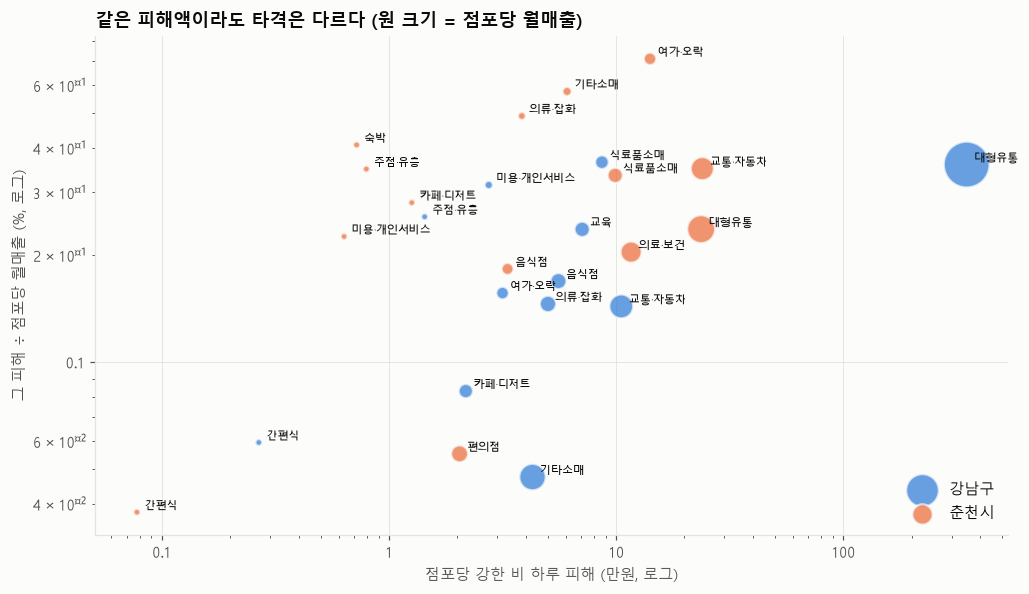

In [12]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for r in REGIONS:
    d = pos[pos['region'] == r]
    ax.scatter(d['점포당 하루 피해(만원)'], d['피해 ÷ 월매출(%)'], s=np.clip(d['점포당 월매출(만원)'] / 30, 20, 900),
               color=REGION_COLOR[r], alpha=0.7, edgecolor=SURFACE, linewidth=1.5, label=r)
    for _, row in d.iterrows():
        ax.annotate(row['industry_group'], (row['점포당 하루 피해(만원)'], row['피해 ÷ 월매출(%)']),
                    textcoords='offset points', xytext=(5, 2), fontsize=7.5, color=INK)
ax.set_xscale('log'); ax.set_yscale('log')
for a in (ax.xaxis, ax.yaxis):
    a.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:g}'))
ax.set_xlabel('점포당 강한 비 하루 피해 (만원, 로그)'); ax.set_ylabel('그 피해 ÷ 점포당 월매출 (%, 로그)')
ax.set_title('같은 피해액이라도 타격은 다르다 (원 크기 = 점포당 월매출)')
ax.legend(loc='lower right')
fig.tight_layout()

**해석 — 가설 1**
- 점포당 강한 비 하루 피해 '금액'은 강남 대형유통이 약 350만원으로 가장 크지만, 점포 월매출이 약 9.7억원이라 타격은 0.36%다.
- 춘천 여가·오락은 하루 피해 14만원으로 25분의 1이지만 **타격은 0.71%로 2배**, 춘천 기타소매·의류·잡화도 0.5~0.6%로 높다.
- 금액 순위와 타격 순위가 다르게 움직인다 → 연간 손실 기준으로 8-1절에서 다시 확인한다.

## 8. 연간 예상 손실 — 지원금 최적화 입력

6개월 피해를 그대로 2배 하면 계절이 치우친다 (여름 장마 포함, 1~6월 없음). 그래서

$$\text{연간 예상 손실}_{u} = \sum_{k \in \text{기상 유형}} \underbrace{\text{유형 }k\text{ 하루 평균 피해}_{u}}_{\text{2025 하반기 모델}} \times \underbrace{\text{유형 }k\text{ 연간 발생 일수}_{r}}_{\text{2015~2024 평균}}$$

- 유형: 강한 비(30mm↑), 보통 비(5~30mm), 폭염(33℃↑ — 과거 일자료는 기온 기준이라 체감 기준보다 적게 잡힘), 한파, 눈
- 하루 피해가 음수(매출 증가)인 유형은 0으로 둔다 (지원은 손실에만)
- 눈은 춘천 적설 관측 공백 때문에 춘천 빈도의 신뢰도가 낮다

In [13]:
def find_file(name):
    for d in [DATA / 'external', DATA]:
        if (d / name).exists():
            return d / name
clim = pd.read_csv(find_file('kma_asos_daily_2015_2024.csv'), usecols=['tm', 'stnId', 'sumRn', 'maxTa', 'minTa'])
clim['region'] = clim['stnId'].map({108: '강남구', 101: '춘천시'})
clim['year'] = clim['tm'].str[:4]
clim['sumRn'] = clim['sumRn'].fillna(0)
freq = clim.groupby(['region', 'year']).agg(
    강한비=('sumRn', lambda s: (s >= 30).sum()), 보통비=('sumRn', lambda s: ((s >= 5) & (s < 30)).sum()),
    폭염=('maxTa', lambda s: (s >= 33).sum()), 한파=('minTa', lambda s: (s <= -12).sum())).groupby('region').mean()
snow_freq = load('weather_climate').groupby('region')['snow_days'].mean()
freq['눈'] = snow_freq
print('연평균 발생 일수 (2015~2024)')
display(freq.round(1))

type_map = {'강한비': dmg['rain_heavy'] == 1, '보통비': dmg['rain_mid'] == 1, '폭염': dmg['heat_33'] == 1,
            '한파': dmg['cold'] == 1, '눈': dmg['snow'] == 1}
per_day = pd.DataFrame({k: dmg[m].groupby(KEYS)['damage_amount'].mean() for k, m in type_map.items()})
annual = per_day.clip(lower=0).fillna(0).mul(freq.reindex(per_day.index.get_level_values(0)).values)
summary = unit.set_index(KEYS)[['n_stores', 'sales_monthly', 'sales_per_store_monthly', 'outsider_share', 'indep_share']].copy()
for k in type_map:
    summary[f'loss_day_{k}'] = per_day[k]
    summary[f'annual_loss_{k}'] = annual[k]
summary['annual_loss'] = annual.sum(axis=1)
summary['annual_loss_per_store'] = summary['annual_loss'] / summary['n_stores']
summary['annual_loss_rate'] = summary['annual_loss'] / (summary['sales_monthly'] * 12) * 100
summary['heavy_rate'] = heavy['heavy_rate']
summary = summary.reset_index()
v = summary.sort_values('annual_loss', ascending=False)[KEYS + ['annual_loss', 'annual_loss_per_store', 'annual_loss_rate', 'heavy_rate']].copy()
v['annual_loss'] /= 1e8; v['annual_loss_per_store'] /= 1e4
v.rename(columns={'annual_loss': '연간 예상 손실(억원)', 'annual_loss_per_store': '점포당(만원)',
                  'annual_loss_rate': '연매출 대비(%)', 'heavy_rate': '강한 비 피해율(%)'}).round(2)

연평균 발생 일수 (2015~2024)


,강한비,보통비,폭염,한파,눈
region,,,,,
강남구,13.00,31.60,17.90,4.40,7.60
춘천시,12.00,33.80,19.00,16.80,3.70


,region,industry_group,연간 예상 손실(억원),점포당(만원),연매출 대비(%),강한 비 피해율(%)
4,강남구,대형유통,711.06,"15,731.33",1.35,10.46
9,강남구,음식점,192.81,265.72,0.67,4.85
3,강남구,기타소매,184.91,592.27,0.55,1.40
11,강남구,의류·잡화,123.83,353.91,0.86,3.95
1,강남구,교육,103.06,199.58,0.55,7.54
5,강남구,미용·개인서비스,50.41,138.92,1.32,7.84
17,춘천시,교통·자동차,49.38,960.67,1.17,10.93
19,춘천시,대형유통,46.73,"1,148.05",0.96,7.01
10,강남구,의료·보건,45.92,120.04,0.08,-2.15
24,춘천시,음식점,37.92,113.76,0.52,5.53


In [14]:
r1 = summary['annual_loss'].rank(ascending=False)
r2 = summary['annual_loss_rate'].rank(ascending=False)
print(f"연간 손실 '금액' 순위 vs '연매출 대비 비율' 순위 상관 ρ = {spearmanr(r1, r2)[0]:.2f}")
top_amt = set(summary.nlargest(8, 'annual_loss')['industry_group'] + '·' + summary.nlargest(8, 'annual_loss')['region'])
top_rate = set(summary.nlargest(8, 'annual_loss_rate')['industry_group'] + '·' + summary.nlargest(8, 'annual_loss_rate')['region'])
print('금액 상위 8 ∩ 비율 상위 8:', top_amt & top_rate or '없음')
print('비율 상위 8에만 있는 단위 (금액 기준이면 놓치는 곳):', sorted(top_rate - top_amt))

연간 손실 '금액' 순위 vs '연매출 대비 비율' 순위 상관 ρ = 0.41
금액 상위 8 ∩ 비율 상위 8: {'미용·개인서비스·강남구', '교통·자동차·춘천시', '대형유통·강남구'}
비율 상위 8에만 있는 단위 (금액 기준이면 놓치는 곳): ['기타소매·춘천시', '식료품소매·강남구', '여가·오락·춘천시', '의류·잡화·춘천시', '주점·유흥·춘천시']


**해석 — 가설 2 준비**
- 연간 예상 손실 **금액**은 강남 대형유통(약 711억원)이 압도적이다. 금액 순으로 지원하면 예산 대부분이 대형유통에 간다.
- 연매출 대비 **비율**로 보면 순위가 바뀐다 (금액 순위와 비율 순위의 상관 ρ = 0.41). 비율 상위 8개 중 **춘천 여가·오락(2.2%), 춘천 기타소매(1.7%), 춘천 주점·유흥(1.5%), 강남 식료품소매(1.4%), 춘천 의류·잡화(1.4%)**는 금액 상위 8개에 들지 않는다 → **금액 기준이면 놓치는 업종**이다.
- 대형유통(백화점·대형마트·쇼핑몰)은 소상공인 지원 취지와 맞지 않아, 6단계 최적화에서는 **제외한 경우를 기본**으로 하고 포함한 경우와 비교한다.
- 한계: 눈 빈도(춘천은 관측 공백), 폭염 빈도(과거 일자료는 기온 기준이라 적게 잡힘), 폭염 효과의 계절 혼재.

### 8-1. 데이터 속 A·B·C — 점포당 연간 손실이 비슷한 업종끼리 비교 (가설 1)
점포 하나가 1년에 기상으로 잃는 금액이 **비슷한 구간(연 400만~700만원)**에 있는 업종만 골라, 그 손실이 점포 연매출에서 차지하는 비율을 비교한다.

,업체,region,industry_group,점포당 연간 손실(만원),점포당 연매출(만원),손실 ÷ 연매출(%)
23,A,춘천시,여가·오락,518.47,"23,794.06",2.18
7,B,강남구,식료품소매,410.58,"28,513.76",1.44
25,C,춘천시,의료·보건,566.86,"68,551.87",0.83
3,D,강남구,기타소매,592.27,"108,088.56",0.55


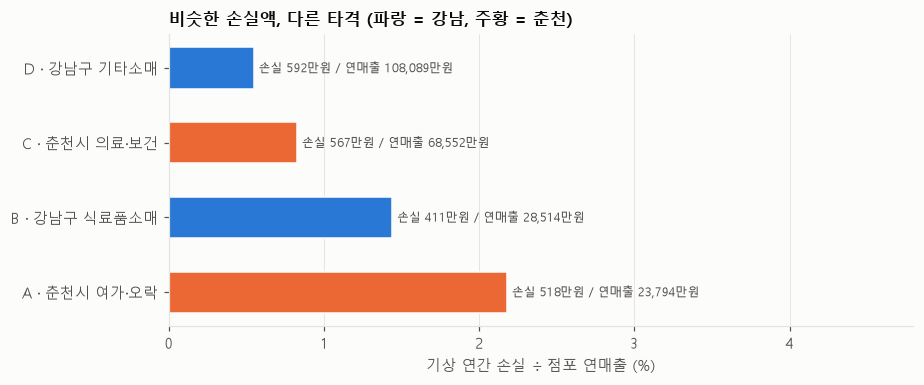

In [15]:
band = summary[(summary['annual_loss_per_store'] >= 400e4) & (summary['annual_loss_per_store'] <= 700e4)].copy()
band['점포당 연매출(만원)'] = band['sales_per_store_monthly'] * 12 / 1e4
band['점포당 연간 손실(만원)'] = band['annual_loss_per_store'] / 1e4
band = band.sort_values('점포당 연매출(만원)')
band['업체'] = [chr(ord('A') + i) for i in range(len(band))]
display(band[['업체', 'region', 'industry_group', '점포당 연간 손실(만원)', '점포당 연매출(만원)', 'annual_loss_rate']].rename(
    columns={'annual_loss_rate': '손실 ÷ 연매출(%)'}).round(2))

fig, ax = plt.subplots(figsize=(8.5, 3.6))
y = np.arange(len(band))
ax.barh(y, band['annual_loss_rate'], color=[REGION_COLOR[r] for r in band['region']], height=0.55, edgecolor=SURFACE)
for i, (_, row) in enumerate(band.iterrows()):
    ax.text(row['annual_loss_rate'] + 0.03, i, f"손실 {row['점포당 연간 손실(만원)']:,.0f}만원 / 연매출 {row['점포당 연매출(만원)']:,.0f}만원",
            va='center', fontsize=8, color=INK2)
ax.set_yticks(y, band['업체'] + ' · ' + band['region'] + ' ' + band['industry_group'])
ax.set_xlabel('기상 연간 손실 ÷ 점포 연매출 (%)')
ax.set_title('비슷한 손실액, 다른 타격 (파랑 = 강남, 주황 = 춘천)', fontsize=11)
ax.grid(axis='y', visible=False)
ax.set_xlim(0, band['annual_loss_rate'].max() * 2.2)
fig.tight_layout()

**해석 — 가설 1 (데이터 속 A·B·C)**
- 점포 하나가 1년에 기상으로 잃는 금액이 **비슷한(400만~700만원) 업종들**인데, 그 손실이 연매출에서 차지하는 비율은 **최대 약 4배** 차이가 난다.
- 점포 연매출이 작은 업종일수록 같은 손실의 무게가 크다 — 사용자 예시(월매출 100만·500만·1,000만원 업체의 100만원 피해)와 같은 구조가 실제 데이터에서도 나타난다.
- → **가설 1 지지**: 피해 '금액'이 같아도 업체 규모에 따라 실제 타격은 다르다. 따라서 지원 기준은 **피해액 ÷ 매출(피해율)**을 함께 봐야 한다.

## 9. 예보 시나리오
최종 모델에 **예보 날씨**를 넣으면 '내일 예상 피해'가 된다. 기준일의 달력·최근 매출 수준은 그대로 두고 기상만 바꾼다.

In [16]:
def scenario(region, date, rain_mm=0.0, feels_like=None, snow=False, rain_slots=None):
    """rain_slots: 시간대별 강수 비율(합 1). 없으면 낮(12~17시) 중심으로 고르게 가정."""
    rows = df[(df['region'] == region) & (df['date'] == pd.Timestamp(date))].copy()
    sh = unit.set_index(KEYS).loc[[(region, g) for g in rows['industry_group']]]
    slots = rain_slots or {'00_05': 0.15, '06_11': 0.25, '12_17': 0.35, '18_23': 0.25}
    expo = sum(sh[f'sales_share_{s}'].values * rain_mm * p for s, p in slots.items())
    rows['log_rain_exposure'] = np.log1p(expo)
    rows['rain_streak'] = int(rain_mm >= 1)
    if feels_like is not None:
        rows['anom_feels_like'] = feels_like - rows['normal_feels_like']
        rows['heat_30_33'] = int(30 <= feels_like < 33); rows['heat_33'] = int(feels_like >= 33)
    rows['snow'] = int(snow); rows['snow_cover'] = int(snow)
    pa, pb = final.predict(rows), final.predict(baseline(rows))
    out = rows[['industry_group']].copy()
    out['평소 예상 매출(백만원)'] = np.expm1(pb) / 1e6
    out['예상 피해율(%)'] = (np.exp(pa - pb) - 1) * 100
    out['예상 피해액(백만원)'] = -out['평소 예상 매출(백만원)'] * out['예상 피해율(%)'] / 100
    out = out.merge(unit[unit['region'] == region][['industry_group', 'n_stores']], on='industry_group')
    out['점포당(만원)'] = out['예상 피해액(백만원)'] * 100 / out['n_stores']
    return out.drop(columns='n_stores').sort_values('예상 피해율(%)').reset_index(drop=True)

print('시나리오 A: 춘천, 평일(2025-09-17, 수), 강수 50mm')
sa = scenario('춘천시', '2025-09-17', rain_mm=50)
display(sa.round(2))
print(f"합계 예상 피해 {sa['예상 피해액(백만원)'].sum():,.0f}백만원 (평소 대비 {sa['예상 피해액(백만원)'].sum() / sa['평소 예상 매출(백만원)'].sum() * 100:.1f}%)")

시나리오 A: 춘천, 평일(2025-09-17, 수), 강수 50mm


,industry_group,평소 예상 매출(백만원),예상 피해율(%),예상 피해액(백만원),점포당(만원)
0,숙박,36.74,-26.15,9.61,1.17
1,여가·오락,386.27,-25.14,97.10,14.11
2,기타소매,422.75,-22.97,97.11,7.13
3,의류·잡화,237.97,-20.76,49.41,4.78
4,교통·자동차,"1,198.59",-13.79,165.33,32.16
5,식료품소매,444.36,-13.30,59.11,12.06
6,카페·디저트,150.47,-12.45,18.73,1.66
7,주점·유흥,37.74,-10.96,4.14,0.68
8,미용·개인서비스,135.72,-9.25,12.56,0.82
9,대형유통,"1,117.94",-8.76,97.89,24.05


합계 예상 피해 836백만원 (평소 대비 10.7%)


In [17]:
print('시나리오 B: 강남, 토요일(2025-08-02), 체감 36℃ 폭염 (비 없음)')
sb = scenario('강남구', '2025-08-02', feels_like=36)
display(sb.round(2))
print(f"합계 {sb['예상 피해액(백만원)'].sum():,.0f}백만원 (양수 = 감소, 음수 = 증가)")

시나리오 B: 강남, 토요일(2025-08-02), 체감 36℃ 폭염 (비 없음)


,industry_group,평소 예상 매출(백만원),예상 피해율(%),예상 피해액(백만원),점포당(만원)
0,미용·개인서비스,"1,684.92",-5.86,98.70,2.72
1,기타소매,"9,102.45",-2.09,190.02,6.09
2,대형유통,"15,606.19",-1.90,297.07,65.72
3,음식점,"9,291.20",-1.49,138.51,1.91
4,의류·잡화,"4,826.70",0.55,-26.52,-0.76
5,간편식,249.28,0.83,-2.06,-0.14
6,편의점,"1,144.61",0.88,-10.04,-1.25
7,카페·디저트,"2,677.72",0.98,-26.31,-0.98
8,교통·자동차,"1,048.21",1.72,-18.06,-3.81
9,식료품소매,677.94,2.29,-15.50,-1.80


합계 -1,518백만원 (양수 = 감소, 음수 = 증가)


**해석**
- **시나리오 A (춘천 평일 50mm)**: 예상 손실 약 8.4억원(평소의 10.7%). 숙박·여가·오락(−25~−26%), 기타소매(−23%), 의류·잡화(−21%)가 가장 크게 줄고, 교육만 늘어난다 (+12%). 지원 발동 시 **방문·외출형 업종을 우선** 지원해야 한다는 근거다.
- **시나리오 B (강남 토요일 체감 36℃)**: 지역 전체로는 오히려 매출이 늘어난다 (약 +15억원). 감소하는 업종은 미용·개인서비스(−5.9%), 기타소매(−2.1%), 대형유통(−1.9%), 음식점(−1.5%)이고, 숙박·교육·의료·보건은 늘어난다. 폭염은 **'전체 피해'가 아니라 '업종 간 소비 이동'**이다 (계절 혼재 가능성은 6절 주의 참고).
- 이 함수는 6단계에서 **예보 기반 사전 지원(D-1 발동)** 규칙을 설계할 때 그대로 쓴다.

## 10. 저장·정리

In [18]:
full_dmg = dmg.copy()
full_dmg.to_parquet(PROC / 'damage_daily.parquet', index=False)
summary['heavy_rate_min'] = heavy['heavy_rate_min'].reindex(pd.MultiIndex.from_frame(summary[KEYS])).values
summary['heavy_rate_max'] = heavy['heavy_rate_max'].reindex(pd.MultiIndex.from_frame(summary[KEYS])).values
summary.to_parquet(PROC / 'damage_unit_summary.parquet', index=False)
coef.to_parquet(PROC / 'damage_model_coef.parquet', index=False)
metrics.to_parquet(PROC / 'damage_model_metrics.parquet', index=False)
print('저장:', 'damage_daily', full_dmg.shape, '| damage_unit_summary', summary.shape, '| damage_model_coef', coef.shape)

저장: damage_daily (5100, 19) | damage_unit_summary (30, 23) | damage_model_coef (180, 10)


## 정리

| 항목 | 결과 |
|---|---|
| 최종 모델 | **선형 회귀 + 지역×업종(30개)별 기상 계수** — 기상 일자 오차 9.87%(가장 낮음), 강한 비 날 11.30% |
| 날씨의 기여 | 날씨 없는 모델 대비 강한 비 날 오차 12.01% → 11.30% |
| 엔지니어링 효과 | LightGBM 원값 기상 → 사건 변수: 기상 일자 오차 11.07% → 10.40% |
| 교차 확인 | 강한 비 효과 순위: 최종 모델 vs EDA 회귀 ρ = 0.71 |
| 기상 피해 (7/15~12/31) | 강한 비 날 강남 −4.2%(상한), 춘천 −8.3% / 손실 합계 강남 약 2,176억원·춘천 약 267억원 (신한카드 기준) |
| **가설 1** | 점포당 연간 손실이 비슷한 업종끼리도 연매출 대비 타격은 최대 약 4배 차이 → **지지** |
| **가설 2 (준비)** | 연간 손실 금액 순위 ≠ 비율 순위 (ρ = 0.41), 금액 기준이면 춘천 여가·오락·주점 등 고타격 업종을 놓침 → 6단계에서 배분 비교 |
| **가설 3** | 13/30 단위가 기상 유형별로 반응 방향이 바뀜 (비·눈 ↓ / 폭염 ↑ 등) → **지지** (폭염 쪽은 방향 참고) |
| 산출물 | `damage_daily`, `damage_unit_summary`(연간 예상 손실·점포당·비율, 강한 비 피해율 범위), `damage_model_coef` |
| 한계 | 6개월·2개 지역, 폭염 효과의 계절 혼재, 눈·한파 표본 적음, 금액은 신한카드 기준(시장 전체보다 작음) |